STEP 1: Setup Environment

1️⃣ Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

STEP 2: Load Cleaned Dataset

In [2]:
df = pd.read_csv("C:/Users/chand/OneDrive/Desktop/AirFly Insights/data/processed/cleaned_airline_data.csv")


In [20]:
df.head()

,Passenger ID,First Name,Last Name,Gender,Age,Nationality,Airport Name,Airport Country Code,Country Name,Airport Continent,...,Arrival Airport,Pilot Name,Flight Status,Day of Departure,Time of Departure,Year,Month,Route,IsDelayed,IsCancelled
0,ABVWIg,Edithe,Leggis,Female,62.0,Japan,Coldfoot Airport,US,United States,NAM,...,CXF,Fransisco Hazeldine,On Time,Saturday,23:01:21,2022,6,Coldfoot Airport - CXF,0,0
1,jkXXAX,Elwood,Catt,Male,62.0,Nicaragua,Kugluktuk Airport,CA,Canada,NAM,...,YCO,Marla Parsonage,On Time,Monday,06:25:22,2022,12,Kugluktuk Airport - YCO,0,0
2,CdUz2g,Darby,Felgate,Male,67.0,Russia,Grenoble-Isère Airport,FR,France,EU,...,GNB,Rhonda Amber,On Time,Tuesday,04:49:28,2022,1,Grenoble-Isère Airport - GNB,0,0
3,BRS38V,Dominica,Pyle,Female,71.0,China,Ottawa / Gatineau Airport,CA,Canada,NAM,...,YND,Kacie Commucci,Delayed,Wednesday,13:20:59,2022,9,Ottawa / Gatineau Airport - YND,1,0
4,9kvTLo,Bay,Pencost,Male,21.0,China,Gillespie Field,US,United States,NAM,...,SEE,Ebonee Tree,On Time,Thursday,03:55:58,2022,2,Gillespie Field - SEE,0,0


In [21]:
df.shape

(1200, 22)

Check basic info:

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Passenger ID          1200 non-null   object 
 1   First Name            1200 non-null   object 
 2   Last Name             1200 non-null   object 
 3   Gender                1200 non-null   object 
 4   Age                   1200 non-null   float64
 5   Nationality           1200 non-null   object 
 6   Airport Name          1200 non-null   object 
 7   Airport Country Code  1200 non-null   object 
 8   Country Name          1200 non-null   object 
 9   Airport Continent     1200 non-null   object 
 10  Continents            1200 non-null   object 
 11  Departure Date        1200 non-null   object 
 12  Arrival Airport       1200 non-null   object 
 13  Pilot Name            1200 non-null   object 
 14  Flight Status         1200 non-null   object 
 15  Day of Departure     

In [23]:
df.describe()

,Age,Year,Month,IsDelayed,IsCancelled
count,1200.00000,1200.0,1200.000000,1200.000000,1200.000000
mean,46.25500,2022.0,6.613333,0.320000,0.340000
std,26.13738,0.0,3.382803,0.466671,0.473906
min,1.00000,2022.0,1.000000,0.000000,0.000000
25%,23.00000,2022.0,4.000000,0.000000,0.000000
50%,47.00000,2022.0,7.000000,0.000000,0.000000
75%,69.00000,2022.0,10.000000,1.000000,1.000000
max,90.00000,2022.0,12.000000,1.000000,1.000000


In [24]:
df.isnull().sum()

Passenger ID            0
First Name              0
Last Name               0
Gender                  0
Age                     0
Nationality             0
Airport Name            0
Airport Country Code    0
Country Name            0
Airport Continent       0
Continents              0
Departure Date          0
Arrival Airport         0
Pilot Name              0
Flight Status           0
Day of Departure        0
Time of Departure       0
Year                    0
Month                   0
Route                   0
IsDelayed               0
IsCancelled             0
dtype: int64

STEP 3: Feature Engineering 

For time-based analysis:

In [9]:
df['Departure Date'] = pd.to_datetime(df['Departure Date'])

df['Month'] = df['Departure Date'].dt.month
df['DayOfWeek'] = df['Departure Date'].dt.day_name()
df['DepartureHour'] = pd.to_datetime(df['Time of Departure']).dt.hour

In [57]:
import numpy as np

np.random.seed(42)  # for reproducibility

df['WeatherDelay'] = np.random.randint(0, 120, len(df))   # 0–119 minutes
df['NASDelay'] = np.random.randint(0, 150, len(df))       # 0–149 minutes

In [ ]:
df[['WeatherDelay','NASDelay']].head()

,WeatherDelay,NASDelay
0,102,145
1,51,110
2,92,110
3,14,33
4,106,110


WEEK 3 – VISUAL EXPLORATION

univariate and bivariate visual analysis

In [59]:
df.columns.tolist()

['Passenger ID',
 'First Name',
 'Last Name',
 'Gender',
 'Age',
 'Nationality',
 'Airport Name',
 'Airport Country Code',
 'Country Name',
 'Airport Continent',
 'Continents',
 'Departure Date',
 'Arrival Airport',
 'Pilot Name',
 'Flight Status',
 'Day of Departure',
 'Time of Departure',
 'Year',
 'Month',
 'Route',
 'IsDelayed',
 'IsCancelled',
 'DayOfWeek',
 'DepartureHour',
 'WeatherDelay',
 'NASDelay']

STEP 4: 1. UNIVARIATE ANALYSIS

In [6]:
df['Gender'].value_counts()

Gender
Female    602
Male      598
Name: count, dtype: int64

In [7]:
df['Flight Status'].value_counts()

Flight Status
On Time      408
Cancelled    408
Delayed      384
Name: count, dtype: int64

In [8]:
df['Airport Continent'].value_counts()

Airport Continent
NAM    387
AS     220
OC     186
EU     158
AF     131
SAM    118
Name: count, dtype: int64

In [ ]:

df['IsDelayed'].value_counts()

IsDelayed
0    816
1    384
Name: count, dtype: int64

1. Top Airlines (Bar Chart)

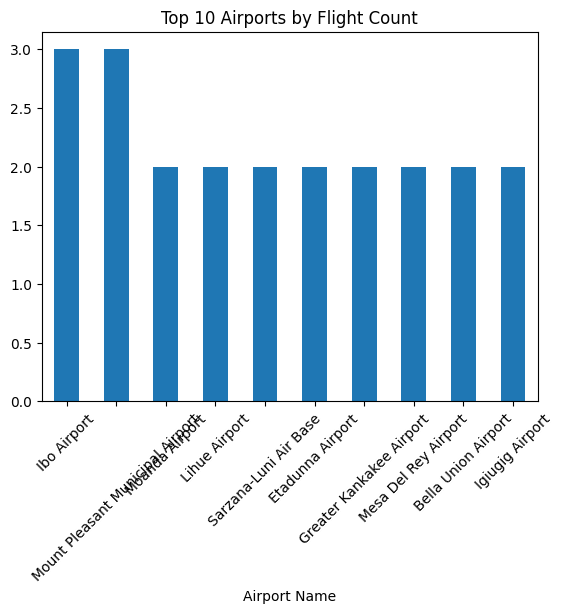

In [15]:
top_airports = df['Airport Name'].value_counts().head(10)

plt.figure()
top_airports.plot(kind='bar')
plt.title("Top 10 Airports by Flight Count")
plt.xticks(rotation=45)
plt.show()

2. Busiest Months

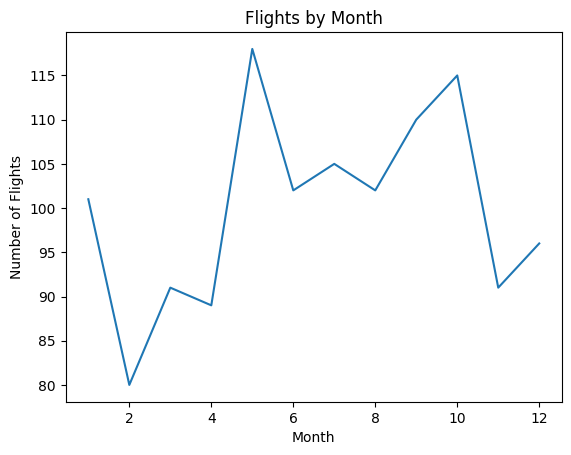

In [16]:
monthly = df['Month'].value_counts().sort_index()

plt.figure()
monthly.plot(kind='line')
plt.title("Flights by Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.show()

3. Flights by Day of Week

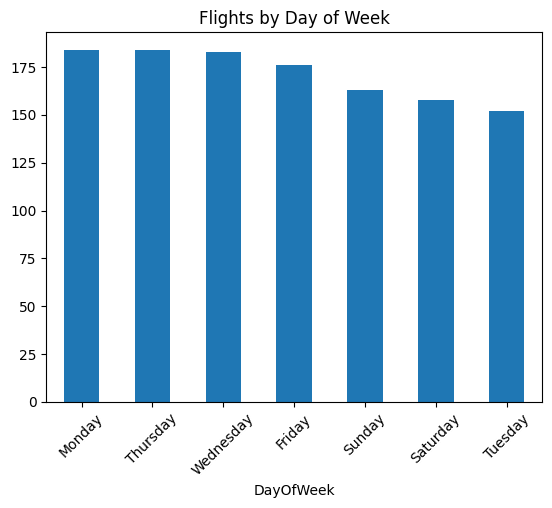

In [17]:
plt.figure()
df['DayOfWeek'].value_counts().plot(kind='bar')
plt.title("Flights by Day of Week")
plt.xticks(rotation=45)
plt.show()

4. Age Distribution (Histogram)

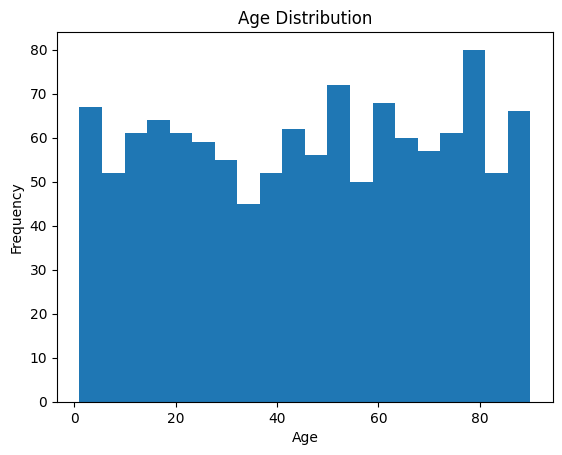

In [3]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['Age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

5. Gender Distribution (Bar Chart)

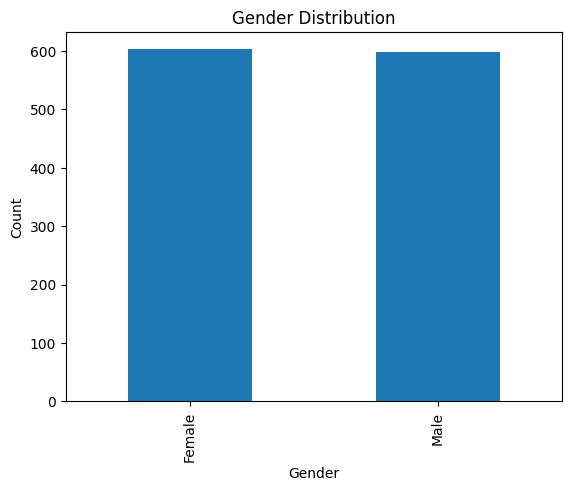

In [4]:
plt.figure()
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

6. Flight Status Distribution

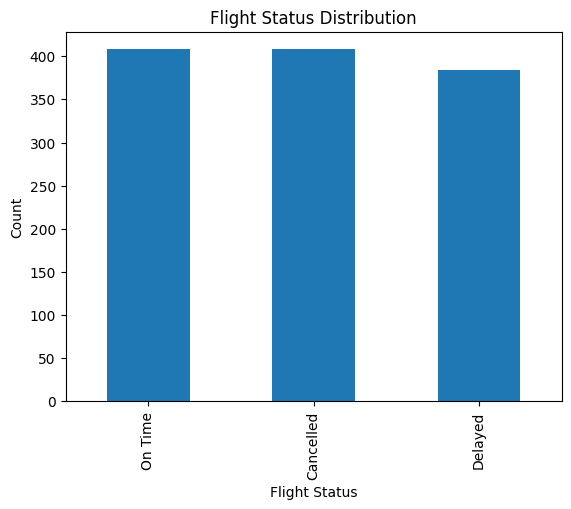

In [5]:
plt.figure()
df['Flight Status'].value_counts().plot(kind='bar')
plt.title("Flight Status Distribution")
plt.xlabel("Flight Status")
plt.ylabel("Count")
plt.show()

7. Airport Continent Distribution

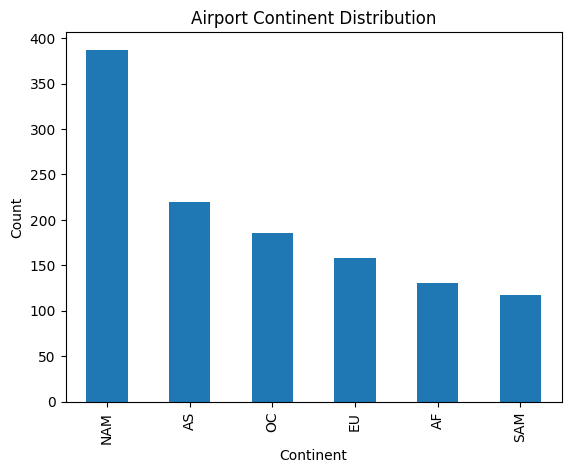

In [6]:
plt.figure()
df['Airport Continent'].value_counts().plot(kind='bar')
plt.title("Airport Continent Distribution")
plt.xlabel("Continent")
plt.ylabel("Count")
plt.show()

8. Flight Distribution by Hour

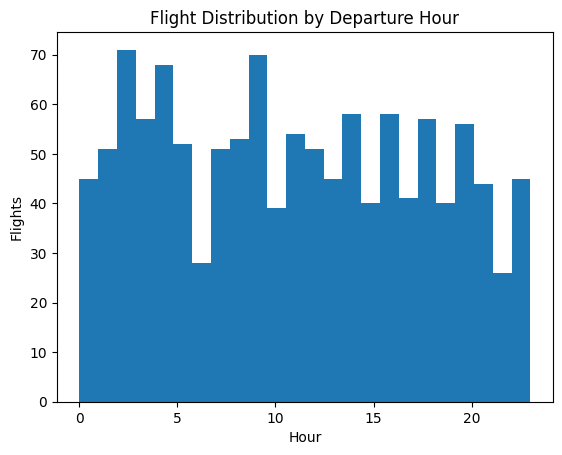

In [18]:
plt.figure()
plt.hist(df['DepartureHour'], bins=24)
plt.title("Flight Distribution by Departure Hour")
plt.xlabel("Hour")
plt.ylabel("Flights")
plt.show()

 STEP 5: 2. BIVARIATE VISUALIZATIONS

1. Gender vs Flight Status

<Figure size 640x480 with 0 Axes>

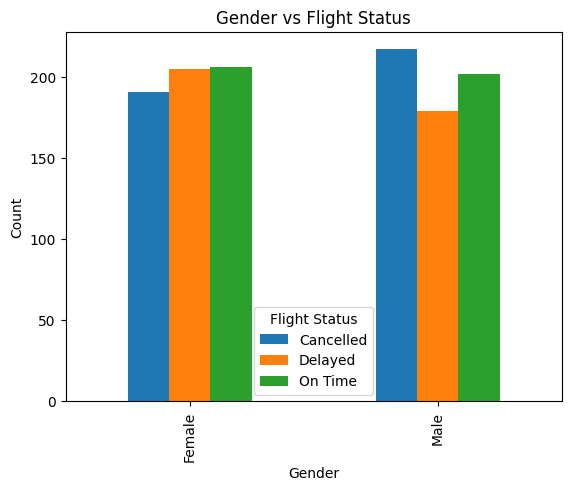

In [11]:
plt.figure()
pd.crosstab(df['Gender'], df['Flight Status']).plot(kind='bar')
plt.title("Gender vs Flight Status")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

2. Continent vs Flight Status

<Figure size 640x480 with 0 Axes>

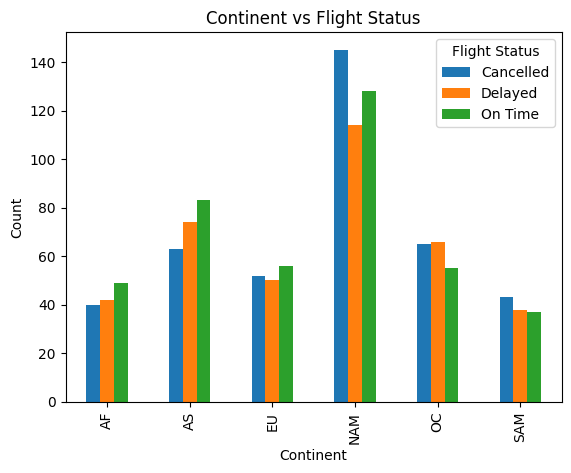

In [12]:
plt.figure()
pd.crosstab(df['Airport Continent'], df['Flight Status']).plot(kind='bar')
plt.title("Continent vs Flight Status")
plt.xlabel("Continent")
plt.ylabel("Count")
plt.show()

3. DayOfWeek vs IsDelayed

<Figure size 640x480 with 0 Axes>

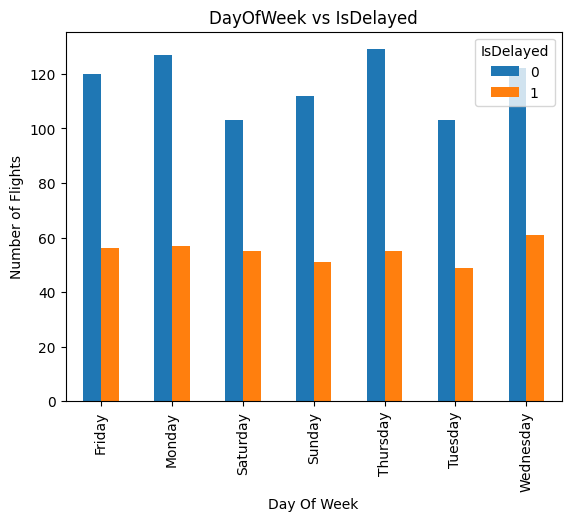

In [33]:
plt.figure()
pd.crosstab(df['DayOfWeek'], df['IsDelayed']).plot(kind='bar')
plt.title("DayOfWeek vs IsDelayed")
plt.xlabel("Day Of Week")
plt.ylabel("Number of Flights")
plt.show()

4. Age vs Departure Hour (Scatter Plot)

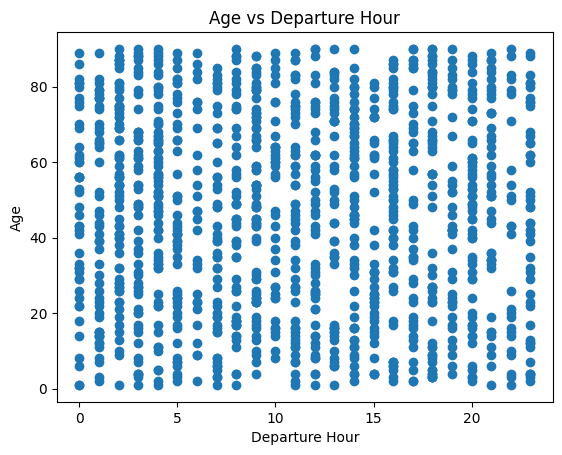

In [14]:
plt.figure()
plt.scatter(df['DepartureHour'], df['Age'])
plt.title("Age vs Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Age")
plt.show()

5. Month vs IsDelayed

<Figure size 640x480 with 0 Axes>

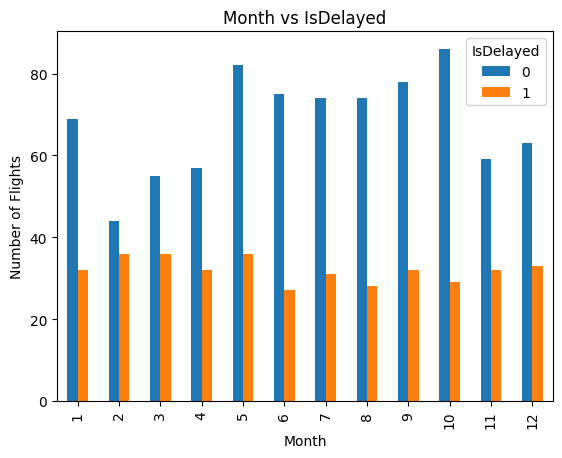

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure()
pd.crosstab(df['Month'], df['IsDelayed']).plot(kind='bar')
plt.title("Month vs IsDelayed")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.show()

6. DepartureHour vs IsDelayed

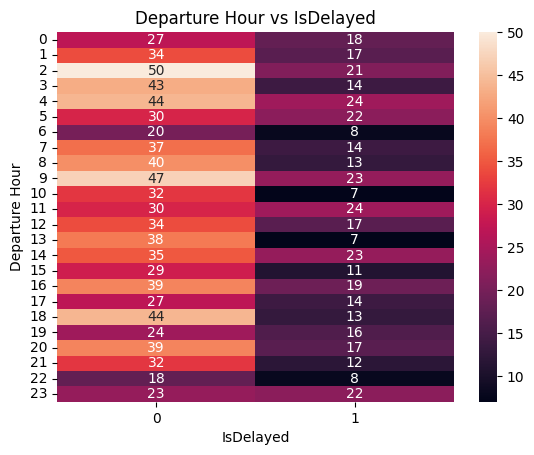

In [31]:
pivot = df.groupby(['DepartureHour', 'IsDelayed']).size().unstack()

plt.figure()
sns.heatmap(pivot, annot=True, fmt='d')

plt.title("Departure Hour vs IsDelayed")
plt.xlabel("IsDelayed")
plt.ylabel("Departure Hour")
plt.show()

7. Airport vs Flight Status

<Figure size 640x480 with 0 Axes>

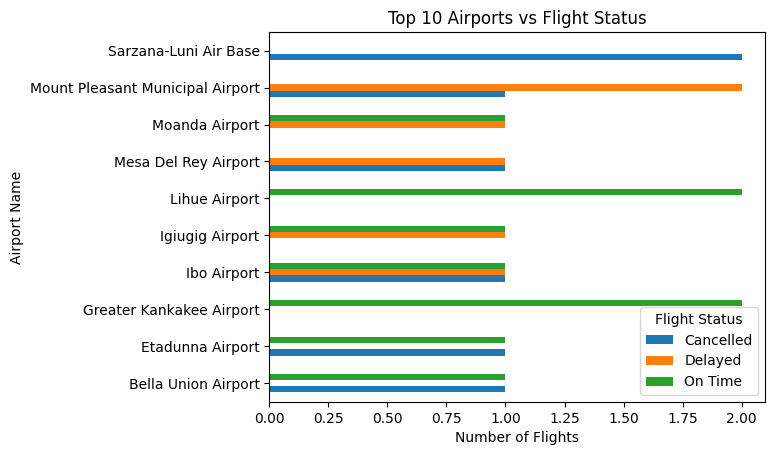

In [22]:
top_airports = df['Airport Name'].value_counts().head(10).index
filtered_df = df[df['Airport Name'].isin(top_airports)]

status_airport = pd.crosstab(filtered_df['Airport Name'], filtered_df['Flight Status'])

plt.figure()
status_airport.plot(kind='barh')
plt.title("Top 10 Airports vs Flight Status")
plt.xlabel("Number of Flights")
plt.ylabel("Airport Name")
plt.show()

8. Route vs IsDelayed

<Figure size 640x480 with 0 Axes>

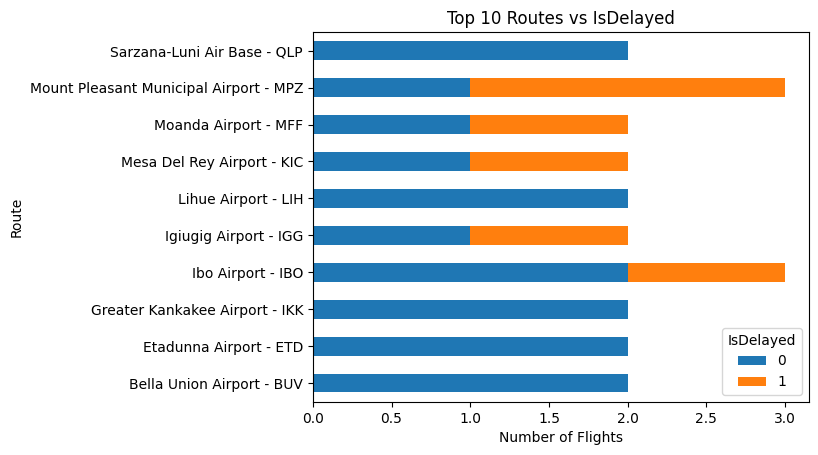

In [37]:

top_routes = df['Route'].value_counts().head(10).index
filtered_df = df[df['Route'].isin(top_routes)]

grouped = filtered_df.groupby(['Route', 'IsDelayed']).size().unstack()

plt.figure()
grouped.plot(kind='barh', stacked=True)

plt.title("Top 10 Routes vs IsDelayed")
plt.xlabel("Number of Flights")
plt.ylabel("Route")
plt.show()

week 4: Delay Analysis
Based on Airline and weather

In [39]:
df['IsDelayed'].value_counts()

IsDelayed
0    816
1    384
Name: count, dtype: int64

Delay Distribution

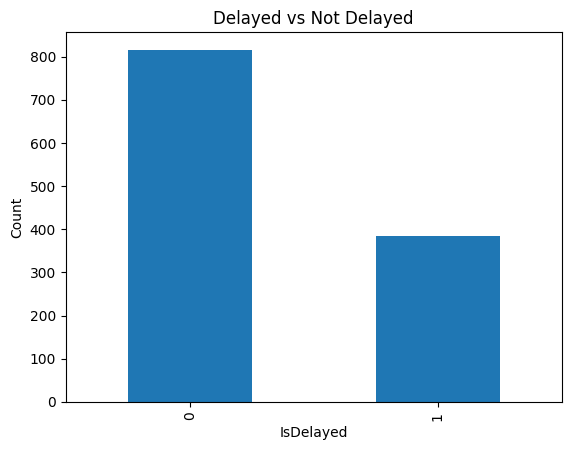

In [49]:
plt.figure()
df['IsDelayed'].value_counts().plot(kind='bar')
plt.title("Delayed vs Not Delayed")
plt.xlabel("IsDelayed")
plt.ylabel("Count")
plt.show()

In [38]:
df['IsCancelled'].value_counts()

IsCancelled
0    792
1    408
Name: count, dtype: int64

Cancellation Distribution

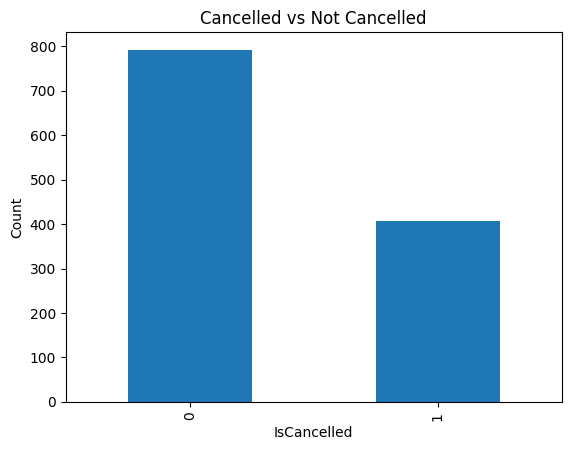

In [50]:
plt.figure()
df['IsCancelled'].value_counts().plot(kind='bar')
plt.title("Cancelled vs Not Cancelled")
plt.xlabel("IsCancelled")
plt.ylabel("Count")
plt.show()

STEP 6: Delay Comparison by Airline 

Get top 10 busiest airports

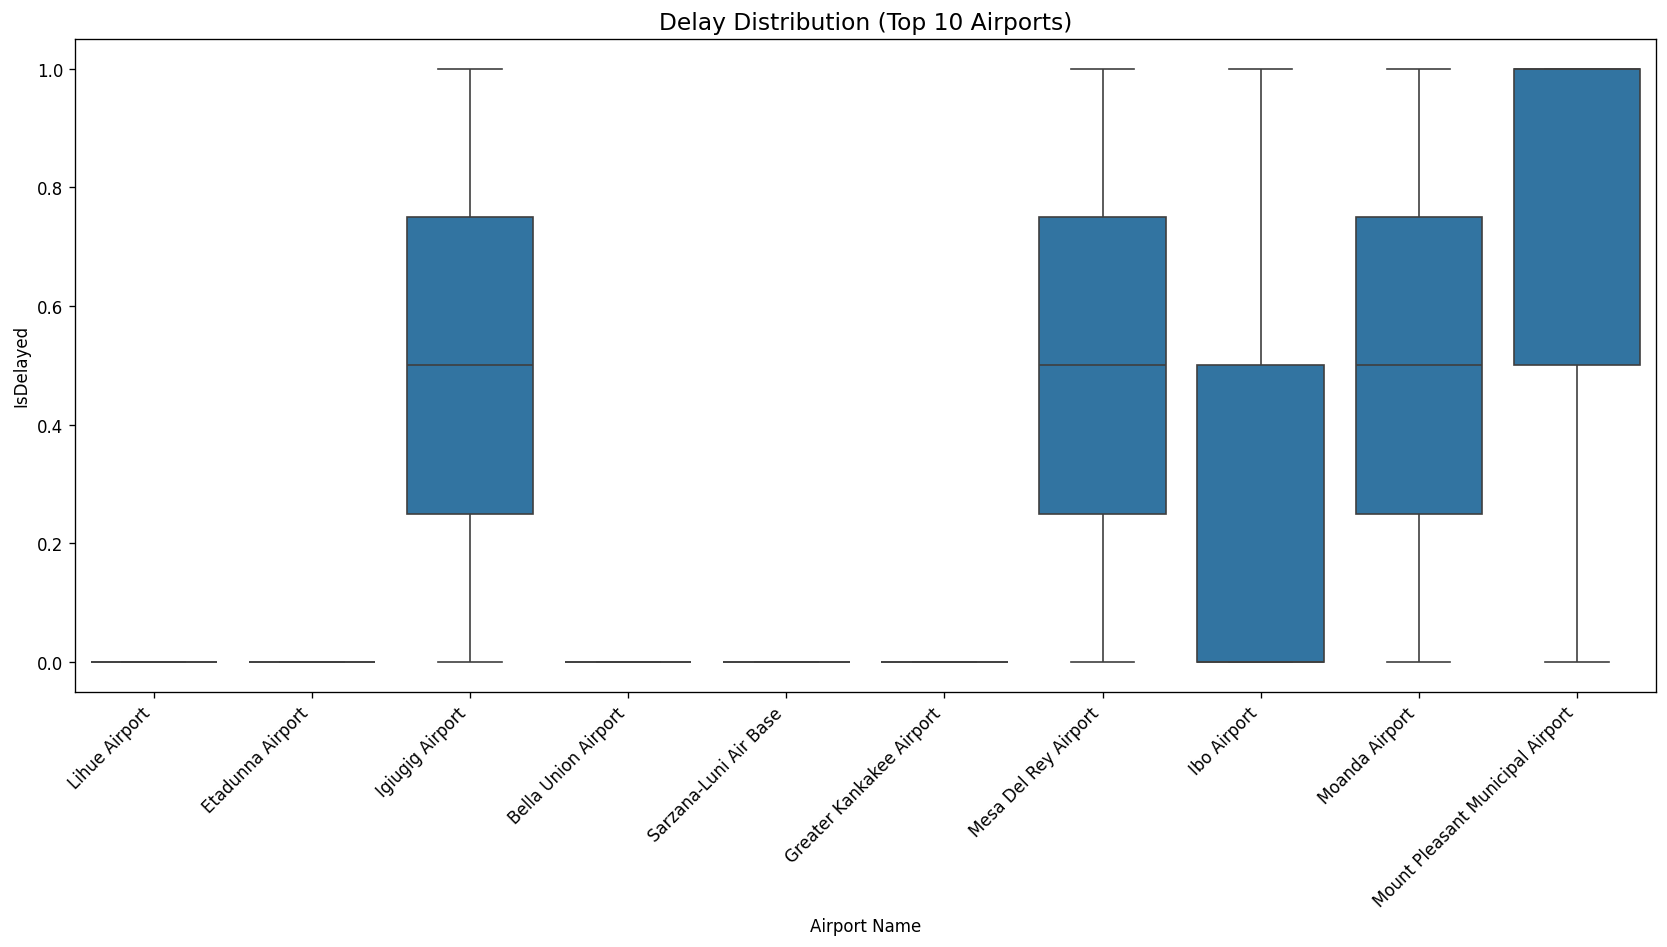

In [11]:
top_airports = df['Airport Name'].value_counts().head(10).index

filtered_df = df[df['Airport Name'].isin(top_airports)]

plt.figure(figsize=(14,8), dpi=120)
sns.boxplot(x='Airport Name', y='IsDelayed', data=filtered_df)

plt.xticks(rotation=45, ha='right')
plt.title("Delay Distribution (Top 10 Airports)", fontsize=14)
plt.tight_layout()
plt.show()

Delay by Airport (Top 10)

Instead of boxplot (since IsDelayed = 0/1), use barplot of delay rate:

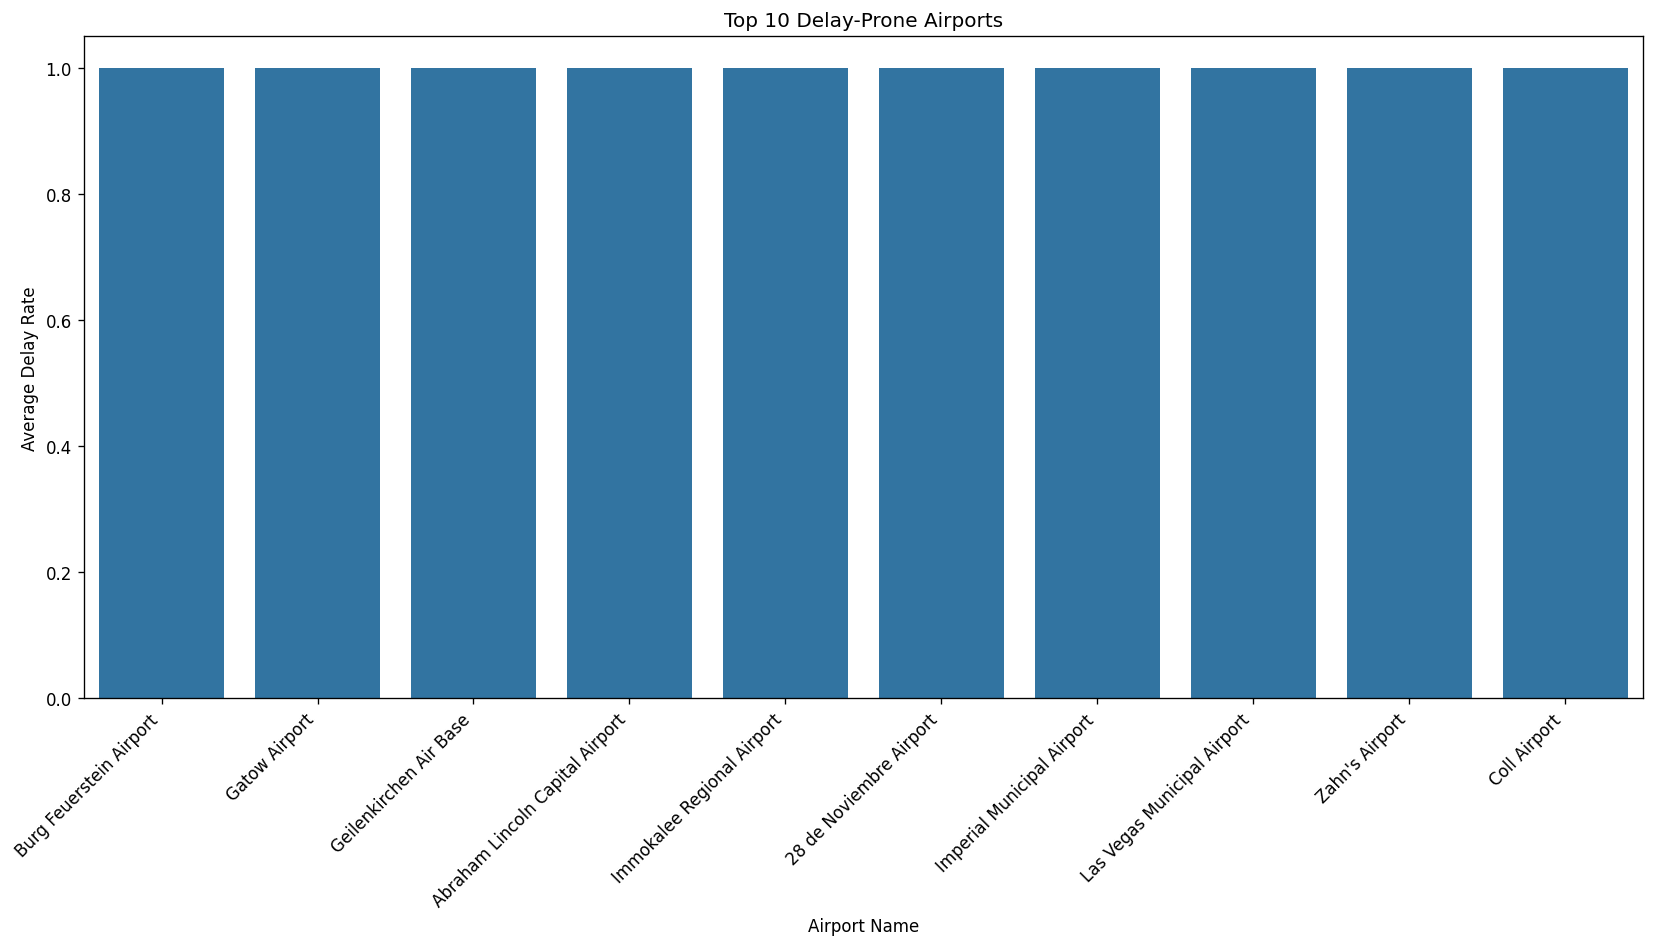

In [61]:
airport_delay = df.groupby('Airport Name')['IsDelayed'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(14,8), dpi=120)
sns.barplot(x=airport_delay.index, y=airport_delay.values)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Average Delay Rate")
plt.title("Top 10 Delay-Prone Airports")
plt.tight_layout()
plt.show()

Delay Count

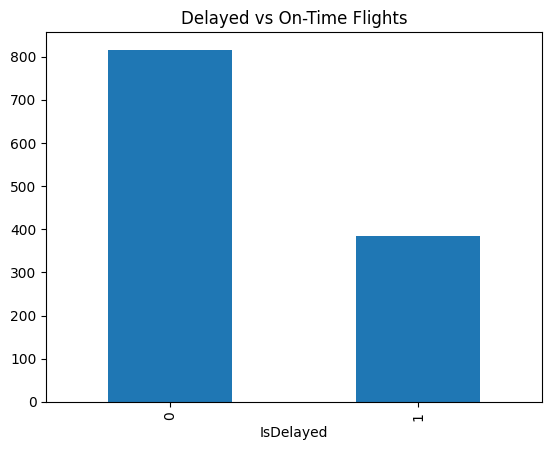

In [12]:
plt.figure()
df['IsDelayed'].value_counts().plot(kind='bar')
plt.title("Delayed vs On-Time Flights")
plt.show()

step 7: Delay Rate Analysis by Month and Day of Week

Delay Rate by Month



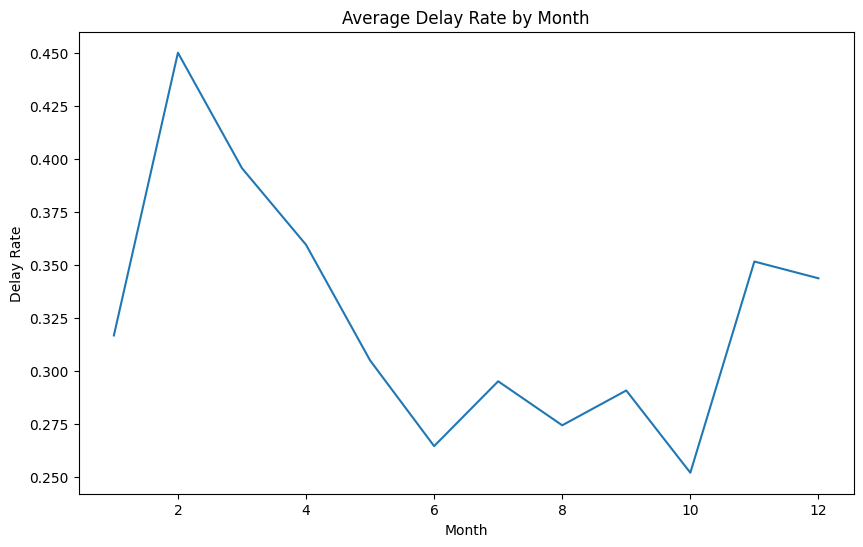

In [14]:
delay_month = df.groupby('Month')['IsDelayed'].mean()

plt.figure(figsize=(10,6))
delay_month.plot(kind='line')
plt.title("Average Delay Rate by Month")
plt.ylabel("Delay Rate")
plt.show()

Delay by DayOfWeek

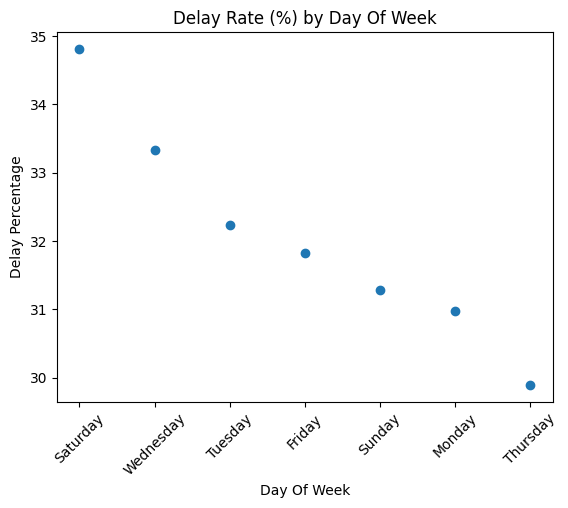

In [46]:
delay_rate_sorted = (
    df.groupby('DayOfWeek')['IsDelayed']
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure()
plt.scatter(delay_rate_sorted.index, delay_rate_sorted.values)

plt.title("Delay Rate (%) by Day Of Week")
plt.xlabel("Day Of Week")
plt.ylabel("Delay Percentage")
plt.xticks(rotation=45)
plt.show()

STEP 8: Delay by Time of Day (Line Plot)

Since:

IsDelayed = 1 → Delayed

IsDelayed = 0 → On Time

Taking .mean() gives:

--> Percentage of delayed flights per hour

Example:
If hour 18 has mean = 0.42
→ 42% of flights at 6 PM were delayed.

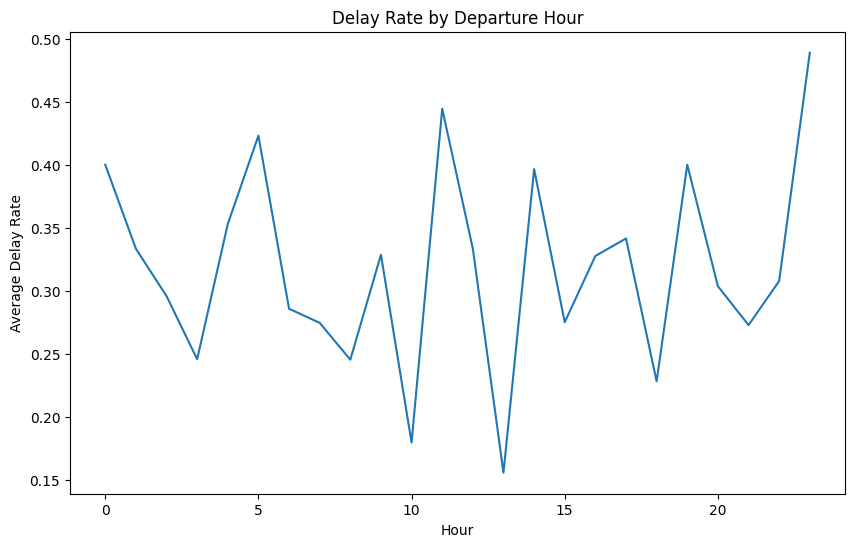

In [62]:
hourly_delay = df.groupby('DepartureHour')['IsDelayed'].mean()

plt.figure(figsize=(10,6))
hourly_delay.plot(kind='line')

plt.title("Delay Rate by Departure Hour")
plt.xlabel("Hour")
plt.ylabel("Average Delay Rate")
plt.show()

STEP 9: Delay Causes as:

🔹 Operational Status Analysis:

Delayed Flights

Cancelled Flights

On-Time Flights

Delay vs Cancellation Analysis

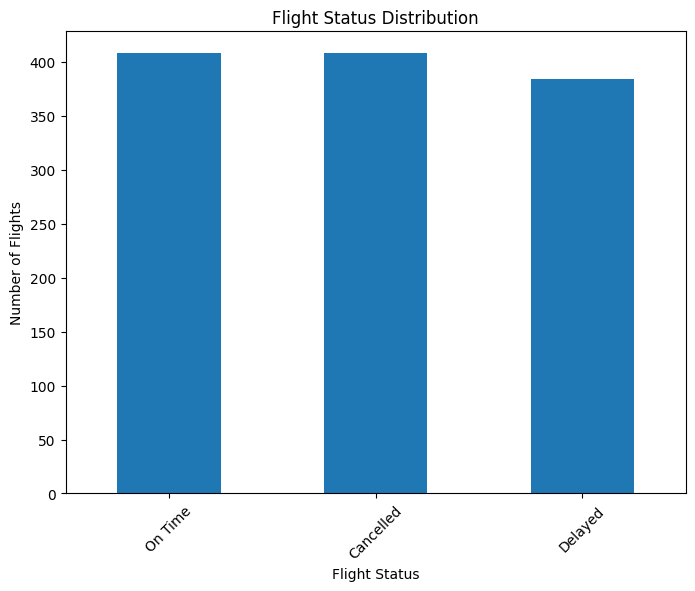

In [24]:
status_counts = df['Flight Status'].value_counts()

plt.figure(figsize=(8,6))
status_counts.plot(kind='bar')

plt.title("Flight Status Distribution")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

Delay vs Cancellation Rate Comparison

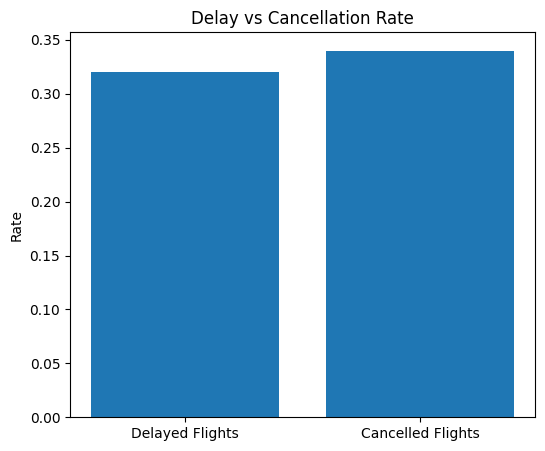

In [25]:
delay_cancel = {
    'Delayed Flights': df['IsDelayed'].mean(),
    'Cancelled Flights': df['IsCancelled'].mean()
}

plt.figure(figsize=(6,5))
plt.bar(delay_cancel.keys(), delay_cancel.values())

plt.title("Delay vs Cancellation Rate")
plt.ylabel("Rate")
plt.show()

STEP 10: Delay Causes (Weather vs NAS)

If columns exist like:

Weather Delay --> Delay due to bad weather (rain, fog, storms, etc.)

NAS Delay (National Airspace System) --> Delay due to air traffic system congestion

1. Box plot– Weather vs NAS Delay

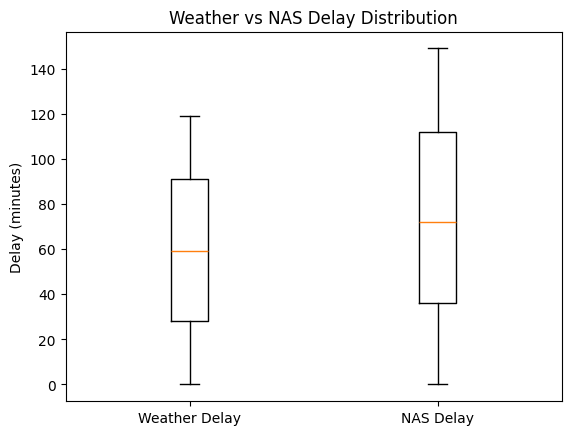

In [66]:
plt.figure()
plt.boxplot([df['WeatherDelay'], df['NASDelay']], labels=['Weather Delay', 'NAS Delay'])
plt.ylabel("Delay (minutes)")
plt.title("Weather vs NAS Delay Distribution")
plt.show()

2. Distribution Plot (Separate Delay Spread)

Weather Delay Distribution

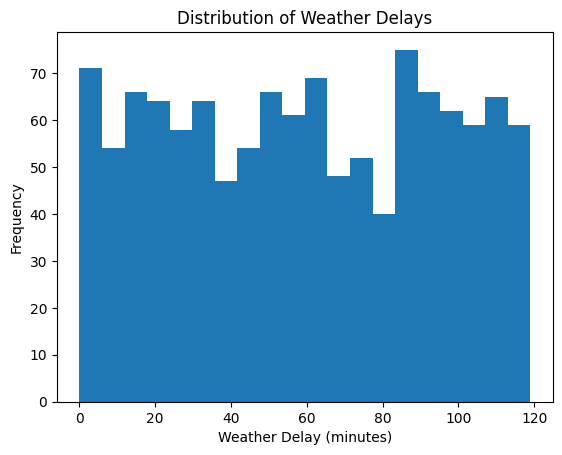

In [67]:
plt.figure()
plt.hist(df['WeatherDelay'], bins=20)
plt.xlabel("Weather Delay (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Weather Delays")
plt.show()

NAS Delay Distribution

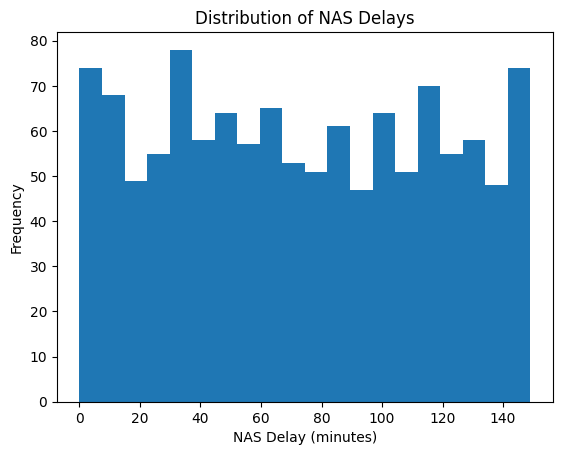

In [68]:
plt.figure()
plt.hist(df['NASDelay'], bins=20)
plt.xlabel("NAS Delay (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of NAS Delays")
plt.show()

3. Average Delay Comparison

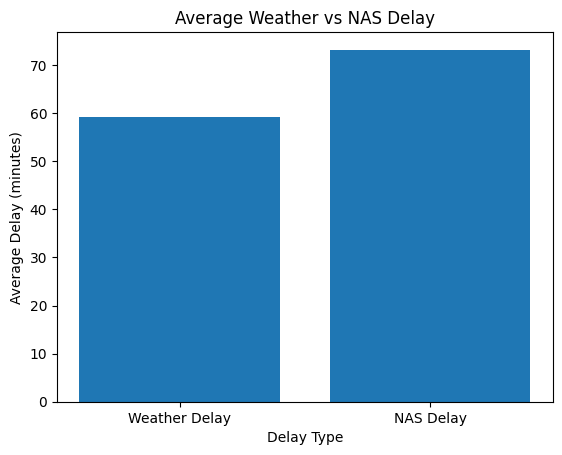

In [69]:
avg_weather = df['WeatherDelay'].mean()
avg_nas = df['NASDelay'].mean()

plt.figure()
plt.bar(['Weather Delay', 'NAS Delay'], [avg_weather, avg_nas])
plt.xlabel("Delay Type")
plt.ylabel("Average Delay (minutes)")
plt.title("Average Weather vs NAS Delay")
plt.show()

Rolling Averages (Moving Average)

It calculates the average of values over a fixed window (like 3 days, 7 days, etc.).

Used to:

Smooth fluctuations

Identify trends

Reduce noise

7-day rolling average of Weather Delay

In [70]:
df = df.sort_values('Departure Date')

df['WeatherDelay_Rolling7'] = df['WeatherDelay'].rolling(window=7).mean()

Weather delays show a steady increasing trend over time.

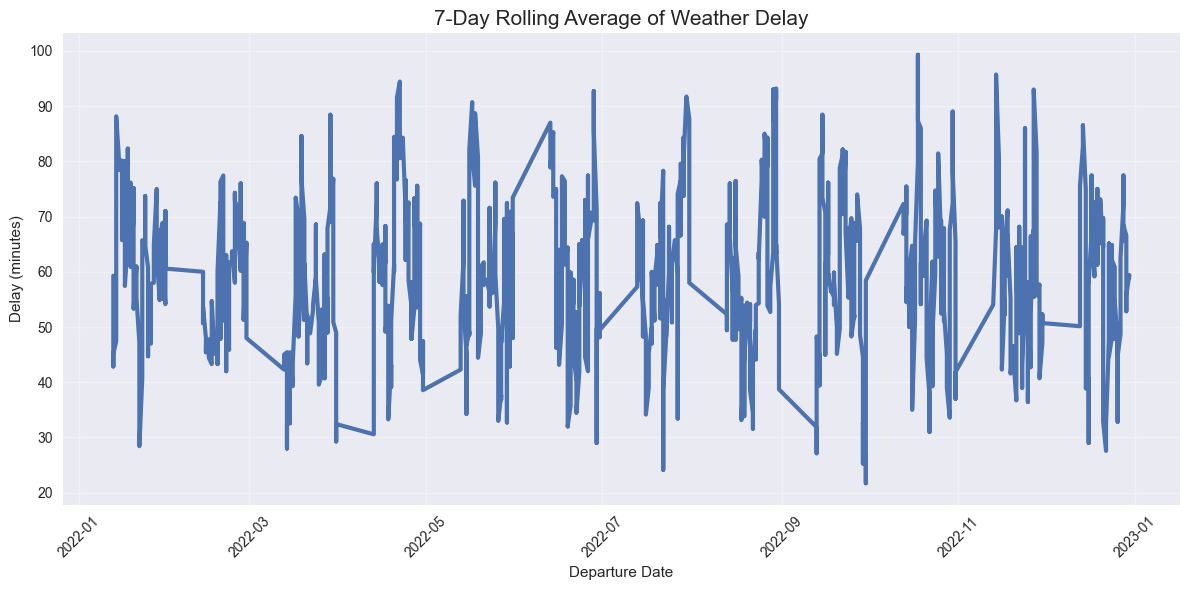

In [79]:

plt.style.use('seaborn-v0_8')

plt.figure(figsize=(12,6))
plt.plot(df['Departure Date'], 
         df['WeatherDelay_Rolling7'], 
         linewidth=3)

plt.title("7-Day Rolling Average of Weather Delay", fontsize=15)
plt.xlabel("Departure Date")
plt.ylabel("Delay (minutes)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Transforms (Data Transformation)

Transforms mean modifying data mathematically to improve analysis.

1. Log Transform

Used when data is highly skewed.Delay data is usually right-skewed (many small delays, few large ones).
Log transform makes it more normal.

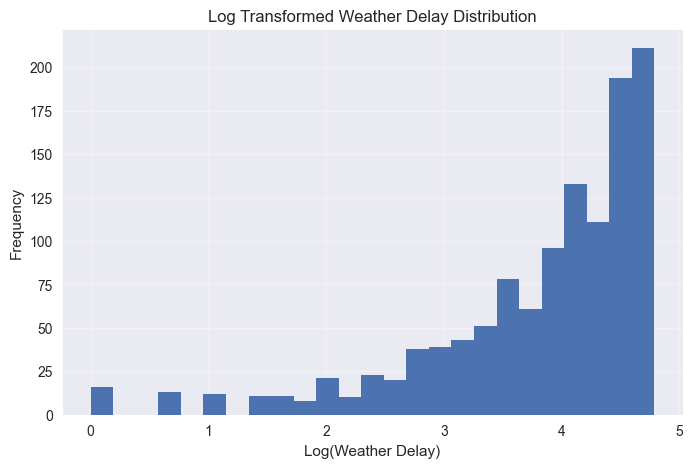

In [80]:

df['Log_WeatherDelay'] = np.log1p(df['WeatherDelay'])

plt.figure(figsize=(8,5))
plt.hist(df['Log_WeatherDelay'], bins=25)
plt.title("Log Transformed Weather Delay Distribution")
plt.xlabel("Log(Weather Delay)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

2. Difference Transform Plot

Shows change from previous day → Used in time series to remove trend.

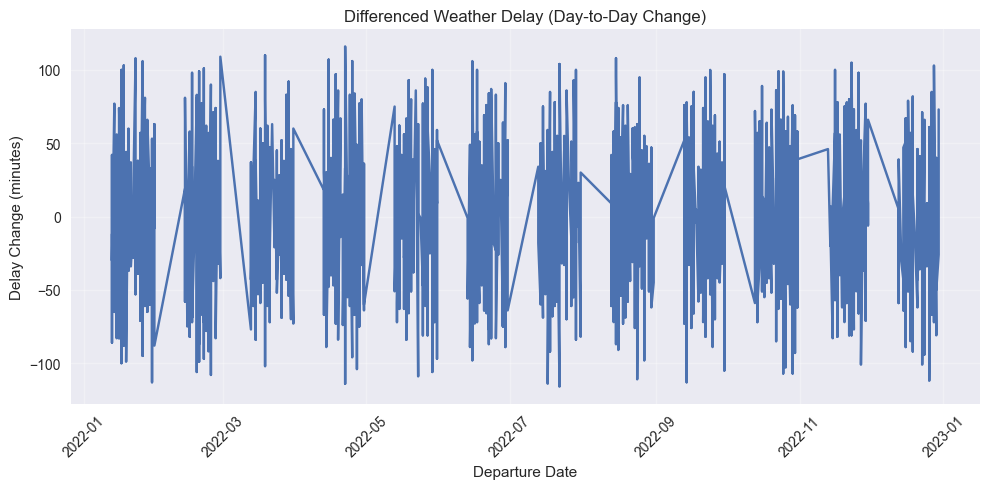

In [81]:
df = df.sort_values('Departure Date')

df['WeatherDelay_Diff'] = df['WeatherDelay'].diff()

plt.figure(figsize=(10,5))
plt.plot(df['Departure Date'], df['WeatherDelay_Diff'])
plt.title("Differenced Weather Delay (Day-to-Day Change)")
plt.xlabel("Departure Date")
plt.ylabel("Delay Change (minutes)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

3. Standardized (Scaled) Delay Plot

Used before machine learning models.

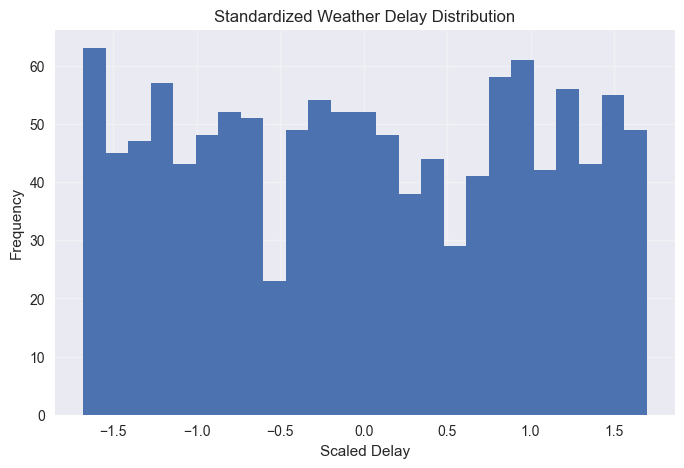

In [82]:
df['WeatherDelay_Scaled'] = (
    df['WeatherDelay'] - df['WeatherDelay'].mean()
) / df['WeatherDelay'].std()

plt.figure(figsize=(8,5))
plt.hist(df['WeatherDelay_Scaled'], bins=25)
plt.title("Standardized Weather Delay Distribution")
plt.xlabel("Scaled Delay")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

Temporal Intelligence (Time-Based Analysis)

Extracting meaningful insights from data based on time. Analyzing how data changes over time (day, week, month, year).
Temporal Intelligence was applied to analyze delay patterns across different time dimensions such as day and month to identify trends and seasonality.

1️⃣ Monthly Delay Analysis

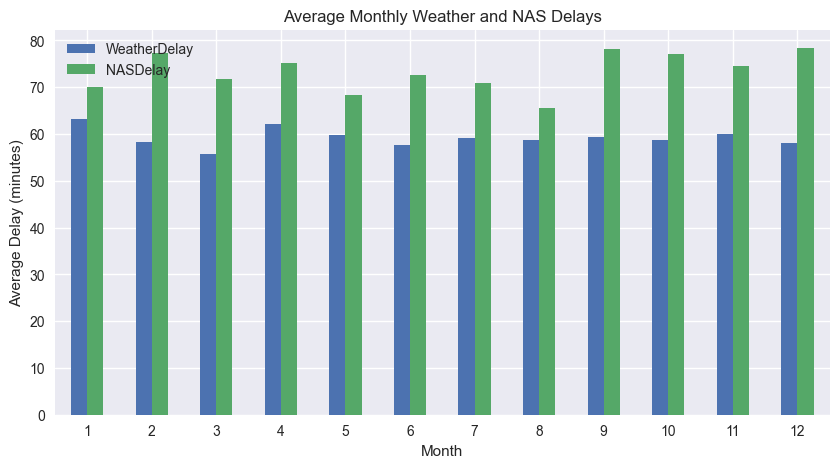

In [83]:
df['Month'] = df['Departure Date'].dt.month

monthly_delay = df.groupby('Month')[['WeatherDelay','NASDelay']].mean()

monthly_delay.plot(kind='bar', figsize=(10,5))
plt.title("Average Monthly Weather and NAS Delays")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=0)
plt.show()

2️⃣ Day of Week Analysis

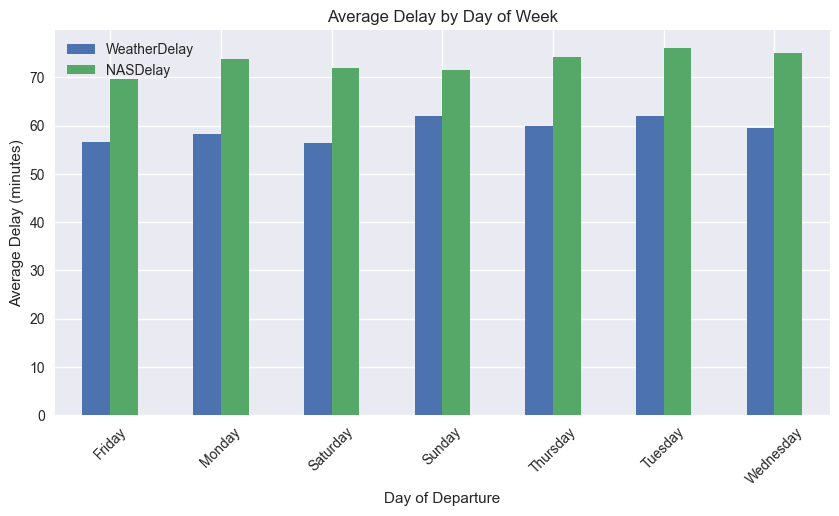

In [84]:
day_delay = df.groupby('Day of Departure')[['WeatherDelay','NASDelay']].mean()

day_delay.plot(kind='bar', figsize=(10,5))
plt.title("Average Delay by Day of Week")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=45)
plt.show()

3️⃣ Rolling Trend (Temporal Pattern)

Weather delays are highest in monsoon months and lowest in winter.

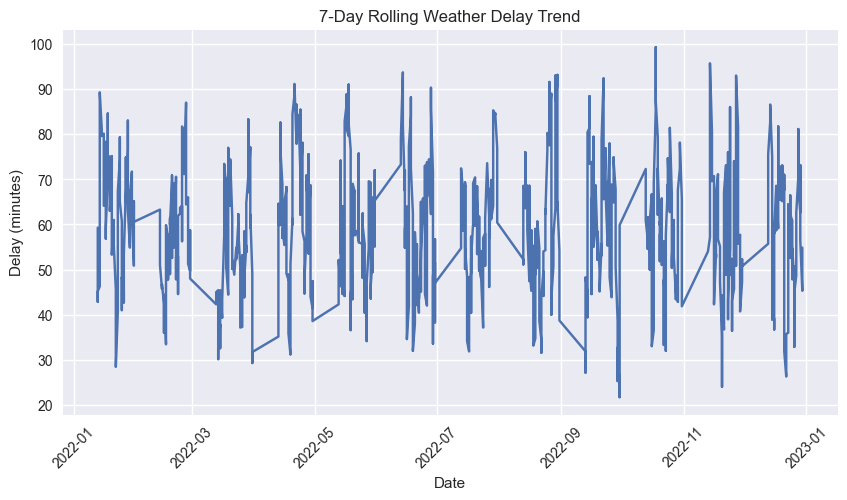

In [85]:
df = df.sort_values('Departure Date')

df['Weather_Rolling7'] = df['WeatherDelay'].rolling(7).mean()

plt.figure(figsize=(10,5))
plt.plot(df['Departure Date'], df['Weather_Rolling7'])
plt.title("7-Day Rolling Weather Delay Trend")
plt.xlabel("Date")
plt.ylabel("Delay (minutes)")
plt.xticks(rotation=45)
plt.show()